In [20]:
import pandas as pd
from pathlib import Path

In [21]:
parent_path = Path.cwd().parent

In [22]:
aggregate_data = pd.read_csv(parent_path / 'data' / 'aggregate_data.csv')
aggregate_data.head()

,date,channel,conversions,revenue,emails_sent,impressions,spend,clicks,week
0,2024-08-01,Email,9,978.96,1999.0,NaN,0.00,110.000000,2024-31
1,2024-08-01,PPC,11,1045.63,NaN,NaN,250.82,0.000000,2024-31
2,2024-08-01,Social Media,4,268.02,NaN,16755.0,172.82,228.000000,2024-31
3,2024-08-02,Email,8,879.14,1845.0,NaN,0.00,90.999583,2024-31
4,2024-08-02,PPC,24,2124.40,NaN,NaN,366.19,0.000000,2024-31


## KPI Calculation

In [23]:
# total spend by channel
total_spend_by_channel = aggregate_data.groupby('channel')['spend'].sum().reset_index()
total_spend_by_channel.rename(columns={'spend': 'total_spend'}, inplace=True)
total_spend_by_channel

,channel,total_spend
0,Email,0.00
1,PPC,107357.76
2,Social Media,53383.98


In [24]:
# total clicks and conversions by channel
total_clicks_conversions = aggregate_data.groupby('channel').agg(
    total_clicks=('clicks', 'sum'),
    total_conversions=('conversions', 'sum')
).reset_index()
total_clicks_conversions

,channel,total_clicks,total_conversions
0,Email,41540.393712,3359
1,PPC,0.000000,5211
2,Social Media,79505.000000,1803


In [25]:
# total revenue by channel
total_revenue = aggregate_data.groupby('channel')['revenue'].sum().reset_index()
total_revenue.rename(columns={'revenue': 'total_revenue'}, inplace=True)
total_revenue

,channel,total_revenue
0,Email,443545.61
1,PPC,529386.11
2,Social Media,142647.07


In [26]:
# click-through rate for social media channel
social_media_data = aggregate_data[aggregate_data['channel'] == 'Social Media']
click_through_rate = social_media_data['clicks'].sum() / social_media_data['impressions'].sum() * 100
click_through_rate

np.float64(1.5025647829280067)

In [27]:
# conversion rate for email and social media
non_ppc_data = aggregate_data[aggregate_data['channel'] != 'PPC']
conversion_rate = non_ppc_data.groupby('channel').agg(
    clicks=('clicks', 'sum'),
    conversions=('conversions', 'sum')
).reset_index()
conversion_rate['conversion_rate'] = conversion_rate['conversions'] / conversion_rate['clicks'] * 100
conversion_rate.drop(columns=['clicks', 'conversions'], inplace=True)
conversion_rate

,channel,conversion_rate
0,Email,8.086105
1,Social Media,2.267782


In [28]:
# cost per click
cost_per_click = non_ppc_data.groupby('channel').agg(
    spend=('spend', 'sum'),
    clicks=('clicks', 'sum')
).reset_index()
cost_per_click['cost_per_click'] = cost_per_click['spend'] / cost_per_click['clicks']
cost_per_click.drop(columns=['spend', 'clicks'], inplace=True)
cost_per_click

,channel,cost_per_click
0,Email,0.000000
1,Social Media,0.671454


In [29]:
# cost per acquisition
cost_per_acquisition = aggregate_data.groupby('channel').agg(
    spend=('spend', 'sum'),
    conversions=('conversions', 'sum')
).reset_index()
cost_per_acquisition['cost_per_acquisition'] = cost_per_acquisition['spend'] / cost_per_acquisition['conversions']
cost_per_acquisition.drop(columns=['spend', 'conversions'], inplace=True)
cost_per_acquisition

,channel,cost_per_acquisition
0,Email,0.000000
1,PPC,20.602142
2,Social Media,29.608419


In [30]:
# return on investment
return_on_investment = aggregate_data[aggregate_data['channel'] != 'Email'].groupby('channel').agg(
    revenue=('revenue', 'sum'),
    spend=('spend', 'sum')
).reset_index()
return_on_investment['roi'] = (return_on_investment['revenue'] - return_on_investment['spend']) / return_on_investment['spend'] * 100
return_on_investment.drop(columns=['revenue', 'spend'], inplace=True)
return_on_investment

,channel,roi
0,PPC,393.104653
1,Social Media,167.209507


## Analysis
#### Which channel has the highest ROI?
The Email channel has the highest ROI due to the fact that it produces revenue with no investment necessary. In a real context, however, the available data does not include the labor and software costs associated with setting up and running an automated email campaign in-house. On the other hand, when considering the total spending for the other campaigns, it is hard to imagine that a simple automated email campaign hosted in-house could reach the hundreds of thousands of dollars in expenses, meaning that it is truly the channel with the highest ROI.

#### Which channels are the most and least expensive for acquiring a customer?
The channel with the lowest cost per acquisition is the email channel, for the reasons outlined above. The most expensive channel, however, is the social media channel, with a single acquisition costing nearly 30 dollars.

#### Which channel is the most effective at converting clicks to sales?
Determining the channel that is the most effective at turning clicks into sales is difficult with the available data, because I do not have access to the number of clicks generated by the PPC campaigns. This means that the only metrics available to evaluate the effectiveness of PPC campaigns are cost, acquisitions, revenue and ROI. Using the available data for the two other channels, email is 4x as effective as social media at converting clicks to sales. However, the much larger number of conversions generated by PPC campaigns compared to the other channels leads me to believe that it would be necessary to look at more information before declaring email to be the most effective channel.

#### Is there an observable performance trend over time for any of the channels?
In the visualizations below, it can be clearly observed that the PPC and Email channels have rather similar performance at the beginning of the dataset, around mid-2024. However, in early 2025, the performance of the two channels diverged immensely, with PPC generating over 50% more revenue than Email in each weekly period until they finally returned to similar revenue levels in mid-2025.

## Visualization

In [32]:
import matplotlib.pyplot as plt
import numpy as np

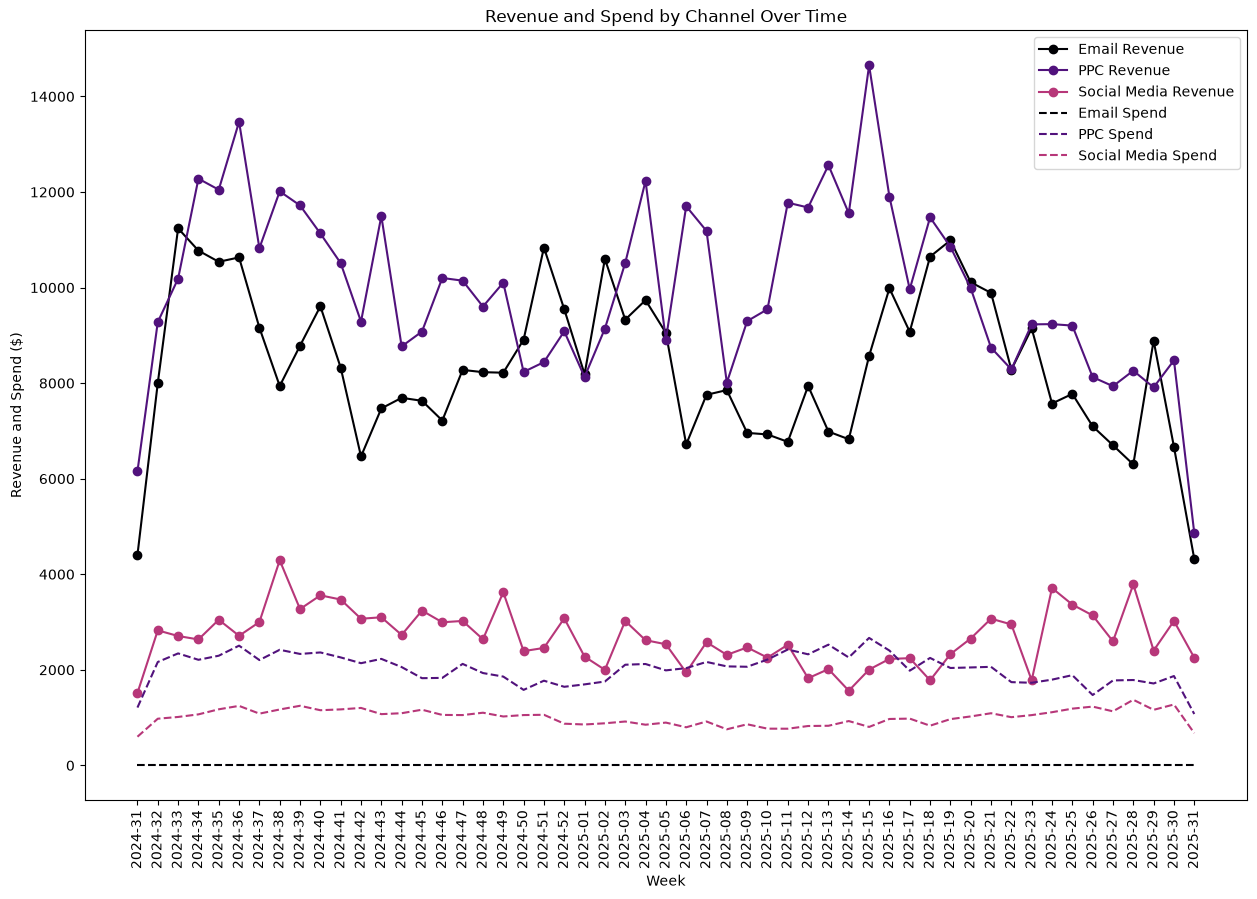

In [41]:
# revenue and spend by week
fig, ax1 = plt.subplots(figsize=(15, 10))
cmap = plt.get_cmap('magma')
colors = cmap(np.linspace(0, 1, 5))

plot_data = aggregate_data.groupby(['channel', 'week']).agg(
    revenue=('revenue', 'sum'),
    spend=('spend', 'sum')
).reset_index()

ax1.plot(
    plot_data[plot_data['channel'] == 'Email']['week'],
    plot_data[plot_data['channel'] == 'Email']['revenue'],
    label='Email Revenue',
    marker='o',
    color=colors[0]
)
ax1.plot(
    plot_data[plot_data['channel'] == 'PPC']['week'],
    plot_data[plot_data['channel'] == 'PPC']['revenue'],
    label='PPC Revenue',
    marker='o',
    color=colors[1]
)
ax1.plot(
    plot_data[plot_data['channel'] == 'Social Media']['week'],
    plot_data[plot_data['channel'] == 'Social Media']['revenue'],
    label='Social Media Revenue',
    marker='o',
    color=colors[2]
)


ax1.plot(
    plot_data[plot_data['channel'] == 'Email']['week'],
    plot_data[plot_data['channel'] == 'Email']['spend'], 
    label='Email Spend', 
    color=colors[0], 
    linestyle='--'
)
ax1.plot(
    plot_data[plot_data['channel'] == 'PPC']['week'],
    plot_data[plot_data['channel'] == 'PPC']['spend'], 
    label='PPC Spend', 
    color=colors[1], 
    linestyle='--'
)
ax1.plot(
    plot_data[plot_data['channel'] == 'Social Media']['week'],
    plot_data[plot_data['channel'] == 'Social Media']['spend'], 
    label='Social Media Spend', 
    color=colors[2], 
    linestyle='--'
)
ax1.set_xlabel('Week')
ax1.tick_params(axis='x', rotation=90)
ax1.set_ylabel('Revenue and Spend ($)')
ax1.set_title('Revenue and Spend by Channel Over Time')
ax1.legend()
plt.show()

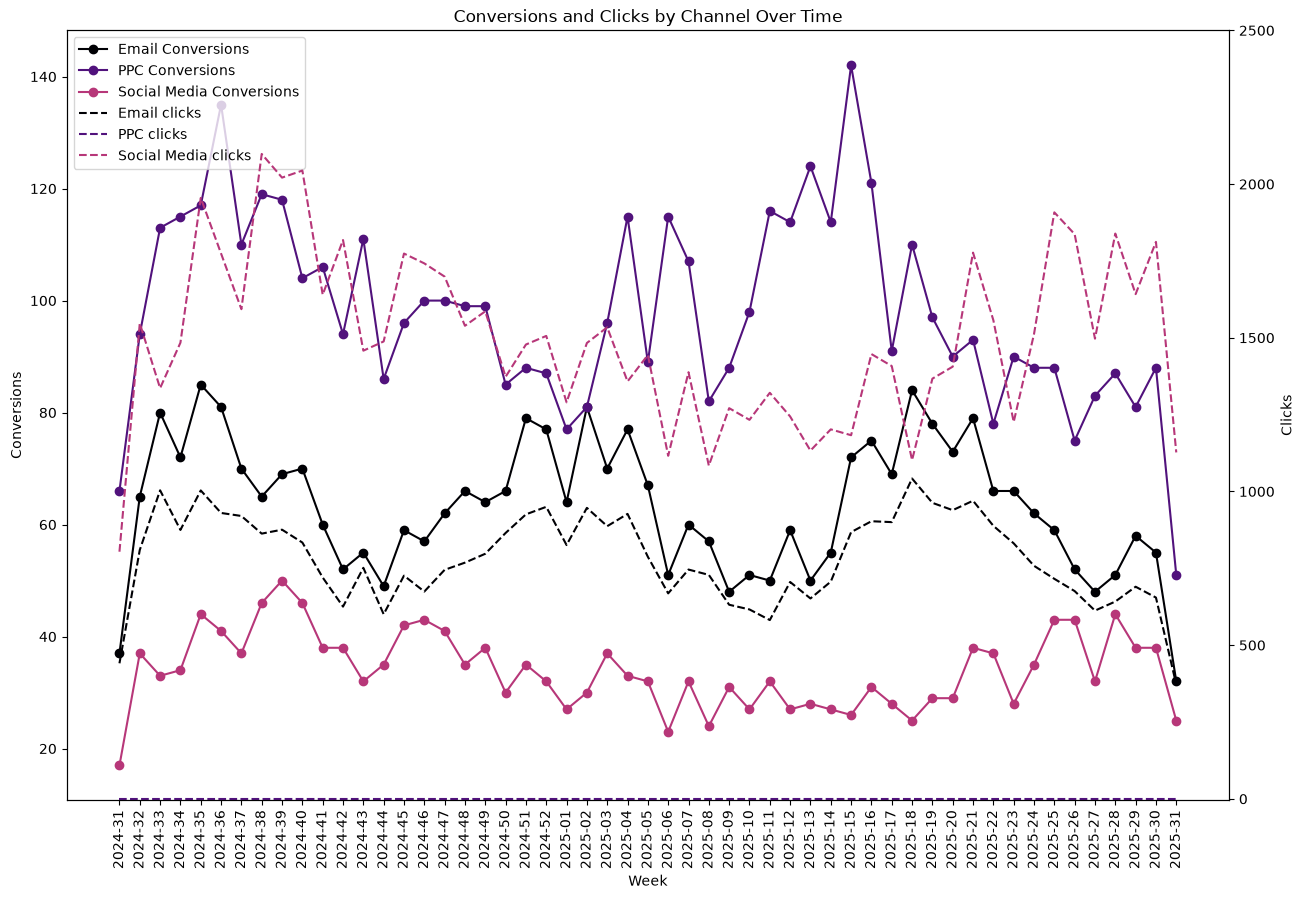

In [48]:
# conversions over time by channel
fig, ax1 = plt.subplots(figsize=(15, 10))
cmap = plt.get_cmap('magma')
colors = cmap(np.linspace(0, 1, 5))

plot_data = aggregate_data.groupby(['channel', 'week']).agg(
    conversions=('conversions', 'sum'),
    clicks=('clicks', 'sum')
).reset_index()

ax1.plot(
    plot_data[plot_data['channel'] == 'Email']['week'],
    plot_data[plot_data['channel'] == 'Email']['conversions'],
    label='Email Conversions',
    marker='o',
    color=colors[0]
)

ax1.plot(
    plot_data[plot_data['channel'] == 'PPC']['week'],
    plot_data[plot_data['channel'] == 'PPC']['conversions'],
    label='PPC Conversions',
    marker='o',
    color=colors[1]
)

ax1.plot(
    plot_data[plot_data['channel'] == 'Social Media']['week'],
    plot_data[plot_data['channel'] == 'Social Media']['conversions'],
    label='Social Media Conversions',
    marker='o',
    color=colors[2]
)

ax2 = ax1.twinx()

ax2.plot(
    plot_data[plot_data['channel'] == 'Email']['week'],
    plot_data[plot_data['channel'] == 'Email']['clicks'], 
    label='Email clicks', 
    color=colors[0], 
    linestyle='--'
)

ax2.plot(
    plot_data[plot_data['channel'] == 'PPC']['week'],
    plot_data[plot_data['channel'] == 'PPC']['clicks'], 
    label='PPC clicks', 
    color=colors[1], 
    linestyle='--'
)

ax2.plot(
    plot_data[plot_data['channel'] == 'Social Media']['week'],
    plot_data[plot_data['channel'] == 'Social Media']['clicks'], 
    label='Social Media clicks', 
    color=colors[2], 
    linestyle='--'
)

ax1.set_xlabel('Week')
ax1.tick_params(axis='x', rotation=90)
ax1.set_ylabel('Conversions')
ax2.set_ylabel('Clicks')
ax2.set_ylim(-5, 2500)
ax1.set_title('Conversions and Clicks by Channel Over Time')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')
plt.show()